In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
from scipy.stats import shapiro, ks_2samp

/Users/imanemokhtatif/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [8]:
# datasets for each plate after quantile normalisation
data_30 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_30_quantile1.csv')
data_31 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_31_quantile1.csv')
data_32= pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_32_quantile1.csv')
data_33 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_33_quantile1.csv')
data_99 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_99_quantile1.csv')
data = pd.concat([data_30, data_31, data_32, data_33, data_99])

/tmp/ipykernel_1114943/438374082.py:2: DtypeWarning: Columns (325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368) have mixed types. Specify dtype option on import or set low_memory=False.
  data_30 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_30_quantile1.csv')
/tmp/ipykernel_1114943/438374082.py:3: DtypeWarning: Columns (365,366,367,368) have mixed types. Specify dtype option on import or set low_memory=False.
  data_31 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_31_quantile1.csv')
/tmp/ipykernel_1114943/438374082.py:4: DtypeWarning: Columns (325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368) have mixed types. Specify dtype optio

In [3]:
data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/2025_5_phase2.csv')

/var/folders/_k/7_jrlrl97z33vpfdszcnhl780000gn/T/ipykernel_7268/1512946447.py:1: DtypeWarning: Columns (457,458) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/2025_5_phase2.csv')


#### Adding light status from design matrices

In [ ]:
# adding light_status_ columns based on the PAR column in the design matrices
# need all files to be names like 20250101_plate-MX_light.csv or 
folder = '/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main//Data/exemples of light on light off'
data = data.copy()

latest_files = {}

for fname in os.listdir(folder):
    if not fname.endswith('.csv'):
        continue
    parts = fname.replace('.csv', '').split('_')
    if len(parts) < 3:
        continue

    try:
        file_date = pd.to_datetime(parts[0], format='%Y%m%d')
    except ValueError:
        continue

    plate_part = parts[1]
    light_part = '_'.join(parts[2:])
    key = (plate_part, light_part)

    if key not in latest_files or file_date > latest_files[key][1]:
        latest_files[key] = (fname, file_date)

for fname, _ in latest_files.values():
    for plate in data['plate'].unique():
        for light in data['light_regime'].unique():
            if (f"_99-" in fname) and (light in fname):  # 99 for phase 1 and 99v1 for phase 2 light statuses
                path = os.path.join(folder, fname)
                try:
                    dm = pd.read_csv(path, sep=';', encoding='utf-8')
                except UnicodeDecodeError:
                    dm = pd.read_csv(path, sep=';', encoding='latin1')

                if 'PAR' in dm.columns and 'No.' in dm.columns:
                    y_cols = [col for col in dm.columns if 'Y(II)' in col]
                    if y_cols:
                        dm = dm[~(dm[y_cols] == 0).all(axis=1)].reset_index(drop=True)
                        dm['No.'] = range(1, len(dm) + 1)

                    dm['light_status'] = np.where(dm['PAR'] > 0, 'light', 'dark')

                    mask = (data['plate'].astype(str) == str(plate)) & (data['light_regime'] == light)
                    measurement_cols = [c for c in data.columns if c.startswith('measurement_time_')]

                    for col in measurement_cols:
                        no_col = str(int(col.replace('measurement_time_', '')) + 1)
                        light_status_col_name = f'light_status_{no_col}'

                        match = dm.loc[dm['No.'].astype(str) == no_col, 'light_status']
                        if not match.empty:
                            light_status = match.values[0]
                            data.loc[mask, light_status_col_name] = light_status
                        else:
                            print(f"Aucun match trouvé pour No. == {no_col} dans {fname}")


In [6]:
# disregard this cell in recent version (phase 2)
folder = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Design_Matrices/'
for fname in os.listdir(folder):
    if (f"_{plate}-" in fname) and (light in fname):
        dm = pd.read_csv(os.path.join(folder, fname), sep=';')
        dm['Date'] = pd.to_datetime(dm['Date'], format='%d.%m.%y')
        

In [ ]:
print(min(df['start_date']), max(df['start_date']))
print(min(df['measurement_time_1']), max(df['start_date']))
print(min(dm['Date']), max(dm['Date']))
print(min(dm['Time']), max(dm['Time']))


2024-06-23 2024-06-23
2024-06-23 11:59:17 2024-06-23
2024-06-23 00:00:00 2024-06-24 00:00:00
00:18:44 23:53:43


#### Plotting the light and dark timepoints for sanity checks


/var/folders/_k/7_jrlrl97z33vpfdszcnhl780000gn/T/ipykernel_7268/4170528508.py:1: DtypeWarning: Columns (333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,376,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Quantile_normalization/2025_5_phase2_light_status_slope_QtilNorm_randeffONLYPLATES_ontimepoints.csv')


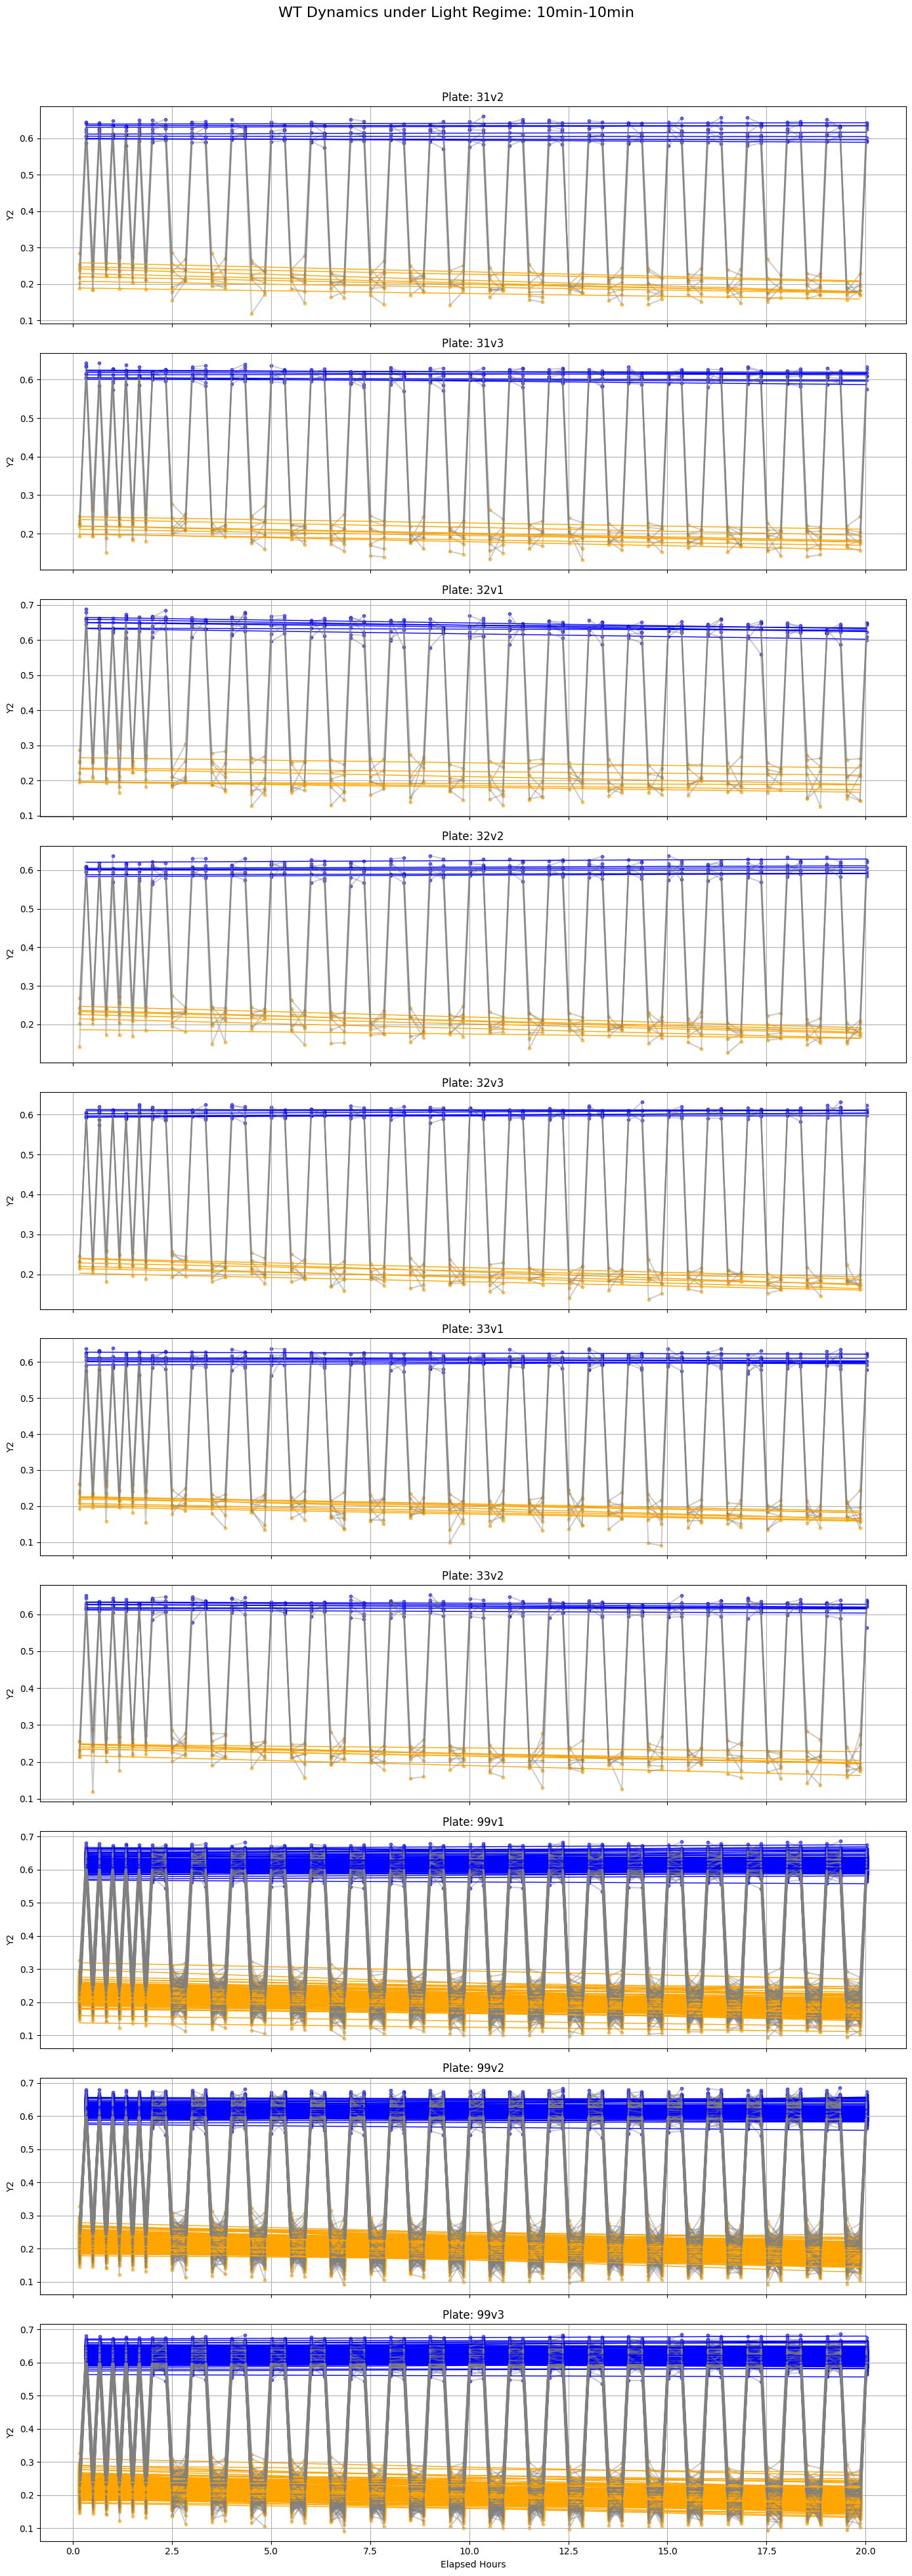

In [6]:
data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Quantile_normalization/2025_5_phase2_light_status_slope_QtilNorm_randeffONLYPLATES_ontimepoints.csv')
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
light_status_cols = [col for col in data.columns if col.startswith('light_status_')]

for col in time_columns:
    data[col] = pd.to_datetime(data[col], format='mixed')

elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)
elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]

data = data.drop(columns=[col for col in data.columns if col.startswith("elapsed_hours_")], errors='ignore')
data = pd.concat([data, elapsed_hours], axis=1)

elapsed_hours_cols = sorted(
    [col for col in data.columns if col.startswith("elapsed_hours_")],
    key=lambda x: int(x.split("_")[-1])
)

#data = data[data['mutated_genes'].isin(['Cre12.g531900'])]
# modifiable
light_regime = '10min-10min'
plates = sorted(data[data['light_regime'] == light_regime]['plate'].unique())
n = len(plates)

fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(14, 4 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, plate in enumerate(plates):
    ax = axes[i]
    data_plate = data[
        (data['light_regime'] == light_regime) &
        (data['plate'] == plate) &
        (data['mutant_ID'].isin(['WT', 'WT CLiP']))
    ]

    for _, row in data_plate.iterrows():
        y2_values = row[y2_columns].astype(float).values
        time_values = row[elapsed_hours_cols[1:]].astype(float).values
        light_status = row[light_status_cols[1:]].astype(str).values

        valid = ~np.isnan(time_values) & ~np.isnan(y2_values) & pd.notna(light_status)
        time_values = time_values[valid]
        y2_values = y2_values[valid]
        light_status = light_status[valid]

        ax.plot(time_values, y2_values, alpha=0.4, color='gray')
        ax.scatter(time_values[light_status == 'light'], y2_values[light_status == 'light'], color='orange', s=10, alpha=0.6)
        ax.scatter(time_values[light_status == 'dark'], y2_values[light_status == 'dark'], color='blue', s=10, alpha=0.6)

        for condition, color in zip(['light', 'dark'], ['orange', 'blue']):
            cond_mask = light_status == condition
            if cond_mask.sum() >= 2:
                x = time_values[cond_mask].reshape(-1, 1)
                y = y2_values[cond_mask]
                model = LinearRegression().fit(x, y)
                #print(condition, model.coef_[0])
                x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
                y_line = model.predict(x_line)
                ax.plot(x_line, y_line, color=color, linewidth=1)

    ax.set_title(f"Plate: {plate}")
    ax.set_ylabel("Y2")
    ax.grid(True)

axes[-1].set_xlabel("Elapsed Hours")
fig.suptitle(f"WT Dynamics under Light Regime: {light_regime}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### compute the slopes and add y2_slope_light and y2_slope_dark columns


In [ ]:
df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1_light_status_slope_randeffONLYPLATES_ontimepoints.csv')#data#pd.concat([data_30, data_31, data_32, data_33, data_99])
plates = np.sort(df['plate'].unique())
lights = ['20h_HL', '20h_ML', '2h-2h', '10min-10min','5min-5min','1min-5min','1min-1min', '30s-30s']   
df_list = []

for plate in plates :
    for light in lights : 
        data = df[df['plate'] == plate]
        data = data[data['light_regime'] == light]
        data['y2_slope_light'] = np.nan
        data['y2_slope_dark'] = np.nan
        y2_cols = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
        light_status_cols = [col for col in data.columns if col.startswith('light_status_')]
        y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
        y2_cols = y2_columns
        time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
        for col in time_columns:
            data[col] = pd.to_datetime(data[col], format='mixed')
        elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)
        elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]
        data = data.drop(columns=[col for col in data.columns if col.startswith("elapsed_hours_")], errors='ignore')
        data = pd.concat([data, elapsed_hours], axis=1)
        elapsed_hours_cols = sorted(
            [col for col in data.columns if col.startswith("elapsed_hours_")],
            key=lambda x: int(x.split("_")[-1]))
        elapsed_cols = elapsed_hours_cols

        cols_exist = all(col in data.columns for col in elapsed_cols + light_status_cols)
        if not cols_exist:
            raise ValueError("Certaines colonnes elapsed_hours_ ou light_status_ sont manquantes.")

        #mvp
        def calculate_slopes(y2_values, time_values, light_status):
            slopes = {'y2_slope_light': np.nan, 'y2_slope_dark': np.nan}
            time_values = row[elapsed_hours_cols[1:]].astype(float).values
            light_status = row[light_status_cols[1:]].astype(str).values
            valid = ~np.isnan(y2_values) & ~np.isnan(time_values) & pd.notna(light_status)
            y2_values = y2_values[valid]
            time_values = time_values[valid]
            light_status = light_status[valid]

            for condition, key in zip(['light', 'dark'], ['y2_slope_light', 'y2_slope_dark']):
                mask = light_status == condition
                if np.sum(mask) >= 2:  
                    x = time_values[mask].reshape(-1, 1)
                    y = y2_values[mask]
                    model = LinearRegression().fit(x, y)
                    slopes[key] = model.coef_[0]
            return slopes
        # compute slopes for each row
        for idx, row in data.iterrows():
            y2_values = row[y2_cols].values.astype(float)
            time_values = row[elapsed_cols].values.astype(float)
            light_status = row[light_status_cols].values

            slopes = calculate_slopes(y2_values, time_values, light_status)
            data.at[idx, 'y2_slope_light'] = slopes['y2_slope_light']
            data.at[idx, 'y2_slope_dark'] = slopes['y2_slope_dark']
        df_list.append(data)
df_final = pd.concat(df_list, ignore_index=True)

/tmp/ipykernel_423253/1222057860.py:2: DtypeWarning: Columns (299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,342,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1_light_status_slope_randeffONLYPLATES_ontimepoints.csv')#data#pd.concat([data_30, data_31, data_32, data_33, data_99])


In [8]:
# we take y2_slope_light as the final slope 
data = df_final.copy()
data['y2_slope'] = data['y2_slope_light']


In [ ]:
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/bayesian_phase2_time_series.csv')
data

## Outlier test after light dark separation and debatching

In [3]:
data=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')
#data['y2_slope'] = data['z_score']

In [12]:
data['plate'] = data['plate'].astype(str)

/tmp/ipykernel_105983/687701723.py:6: DtypeWarning: Columns (2,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,373,374,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv")
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5572.
  res = hypotest_fun_out(*samples, **kwds)
/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, compute

  Light_Regime     N  Shapiro_W     Shapiro_p  Anderson_stat  Anderson_5pct
0  10min-10min  5572   0.971019  3.942554e-32      30.040345          0.786
1    1min-1min  5915   0.992918  1.359773e-16      11.221469          0.786
2    1min-5min  5566   0.992849  4.010667e-16      15.106220          0.786
3       20h_HL  5176   0.992252  3.318149e-16       6.154098          0.786
4       20h_ML  5910   0.983614  1.300805e-25      17.907168          0.786
5        2h-2h  5916   0.981399  3.586278e-27      11.109864          0.786
6      30s-30s  5921   0.997317  9.120920e-09       2.106389          0.786
7    5min-5min  5196   0.994393  2.289464e-13       5.202478          0.786


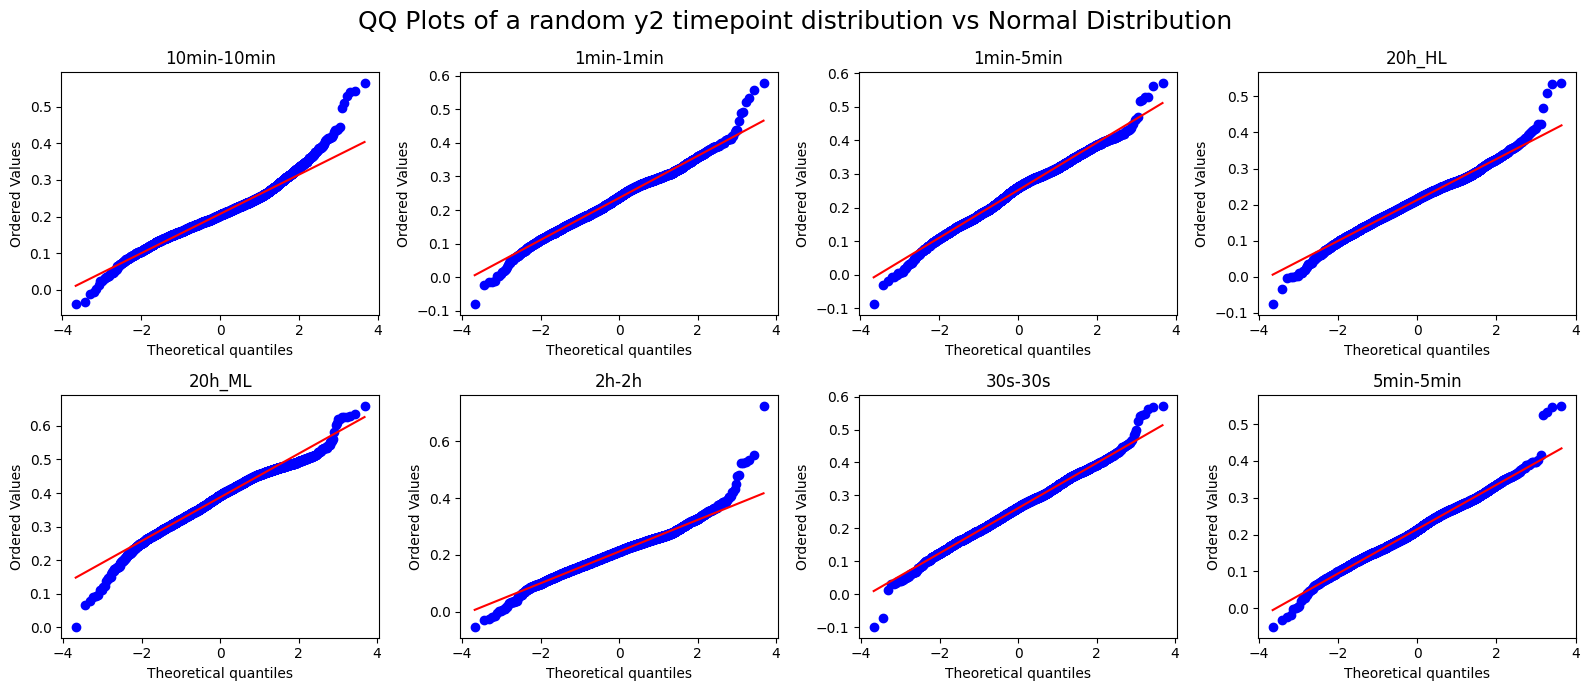

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
# Load your real data
data = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv")
mutant_data = data[~data['plate'].isin(['99v1','99v2','99v3'])]  # Filter for WT and WT CLiP mutants
eps = 1e-6  # small constant to avoid log(0)
#mutant_data['log_slope'] = np.log(mutant_data['y2_slope'] + eps - mutant_data['y2_slope'].min() + 1)
# Function: normality metrics
def normality_metrics(data, column="y2_1", group="light_regime"):
    results = []
    for regime, group_df in data.groupby(group):
        values = group_df[column].dropna()
        if len(values) > 3:
            shapiro_stat, shapiro_p = stats.shapiro(values)
            ad_stat, crit_vals, sig_levels = stats.anderson(values, dist="norm")
            results.append({
                "Light_Regime": regime,
                "N": len(values),
                "Shapiro_W": shapiro_stat,
                "Shapiro_p": shapiro_p,
                "Anderson_stat": ad_stat,
                "Anderson_5pct": crit_vals[sig_levels.tolist().index(5.0)]
            })
    return pd.DataFrame(results)

# Compute metrics
results = normality_metrics(mutant_data)
print(results)

# Plot QQ plots in 4x4 grid
light_regimes = sorted(mutant_data['light_regime'].unique())
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, regime in zip(axes, light_regimes):
    slopes = mutant_data.loc[mutant_data['light_regime'] == regime, 'y2_1']
    stats.probplot(slopes, dist="norm", plot=ax)
    ax.set_title(regime)
    ax.get_lines()[1].set_color('red')

# Hide unused axes if fewer than 16 regimes
for ax in axes[len(light_regimes):]:
    ax.axis('off')

plt.suptitle("QQ Plots of a random y2 timepoint distribution vs Normal Distribution", fontsize=18)
plt.tight_layout()
plt.show()


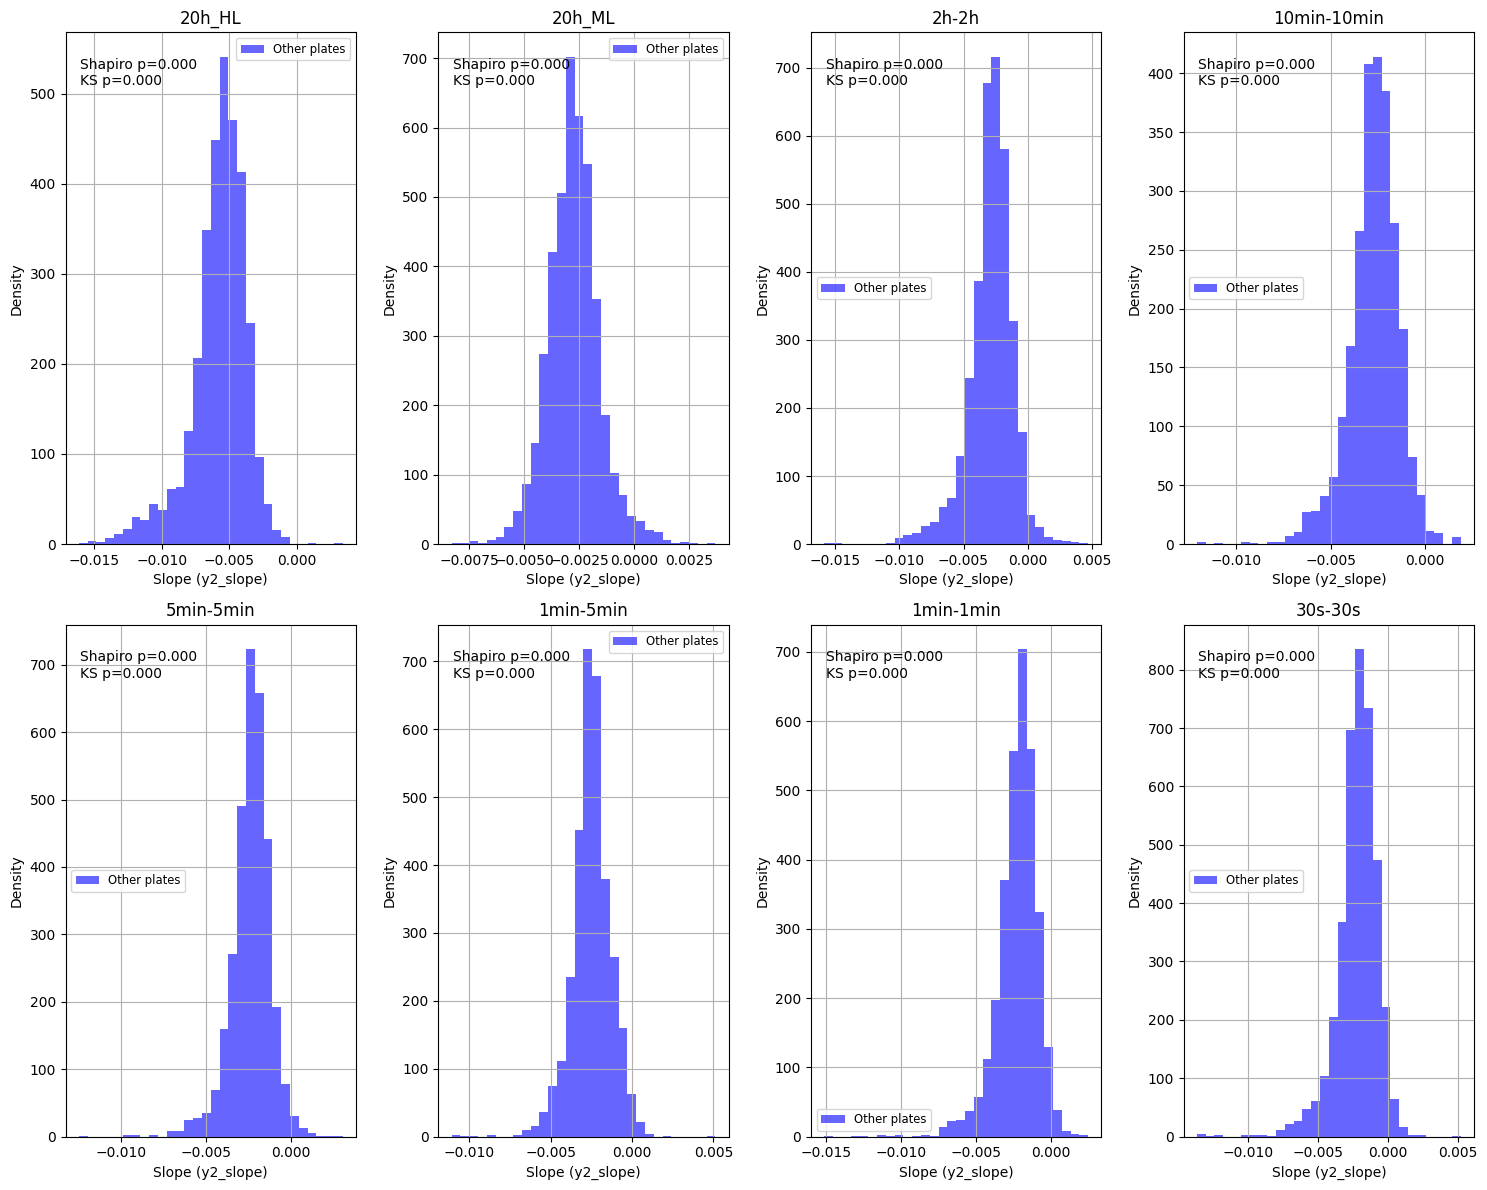

In [5]:
from scipy.stats import norm
from scipy.stats import shapiro, ks_2samp, kstest

normalised_wts = data[(data['mutant_ID'] != 'WT')]# & (data['plate']!='99')]

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

n_rows = 2
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten() 

for i, light_regime in enumerate(light_regimes):
    ax = axes[i]  
    data_light = normalised_wts[normalised_wts['light_regime'] == light_regime]
    
    # slopes = data_light['y2_slope'].dropna()
    slopes_99 = data_light[data_light['plate'].astype(str).str.startswith('99')]['y2_slope'].dropna()
    slopes_other = data_light[data_light['plate'].astype(str).str.startswith('3')]['y2_slope'].dropna()
    
    if slopes_99.empty and slopes_other.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_title(f'{light_regime}')
        ax.axis('off')
        continue

    if not slopes_other.empty:
        ax.hist(slopes_other, bins=30, alpha=0.6, color='blue', label='Other plates')

    if not slopes_99.empty:
        ax.hist(slopes_99, bins=30, alpha=0.6, color='red', label='Plate 99')

    slopes_combined = pd.concat([slopes_99, slopes_other])
    mean, std = norm.fit(slopes_combined)
    shapiro_stat, shapiro_p = shapiro(slopes_combined)
    ks_stat, ks_p = kstest(slopes_combined, 'norm', args=(mean, std))

    ax.text(0.05, 0.95, f'Shapiro p={shapiro_p:.3f}\nKS p={ks_p:.3f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top')
    
    ax.set_title(f'{light_regime}')
    ax.set_xlabel('Slope (y2_slope)')
    ax.set_ylabel('Density')
    ax.legend(fontsize='small')
    ax.grid(True)

for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

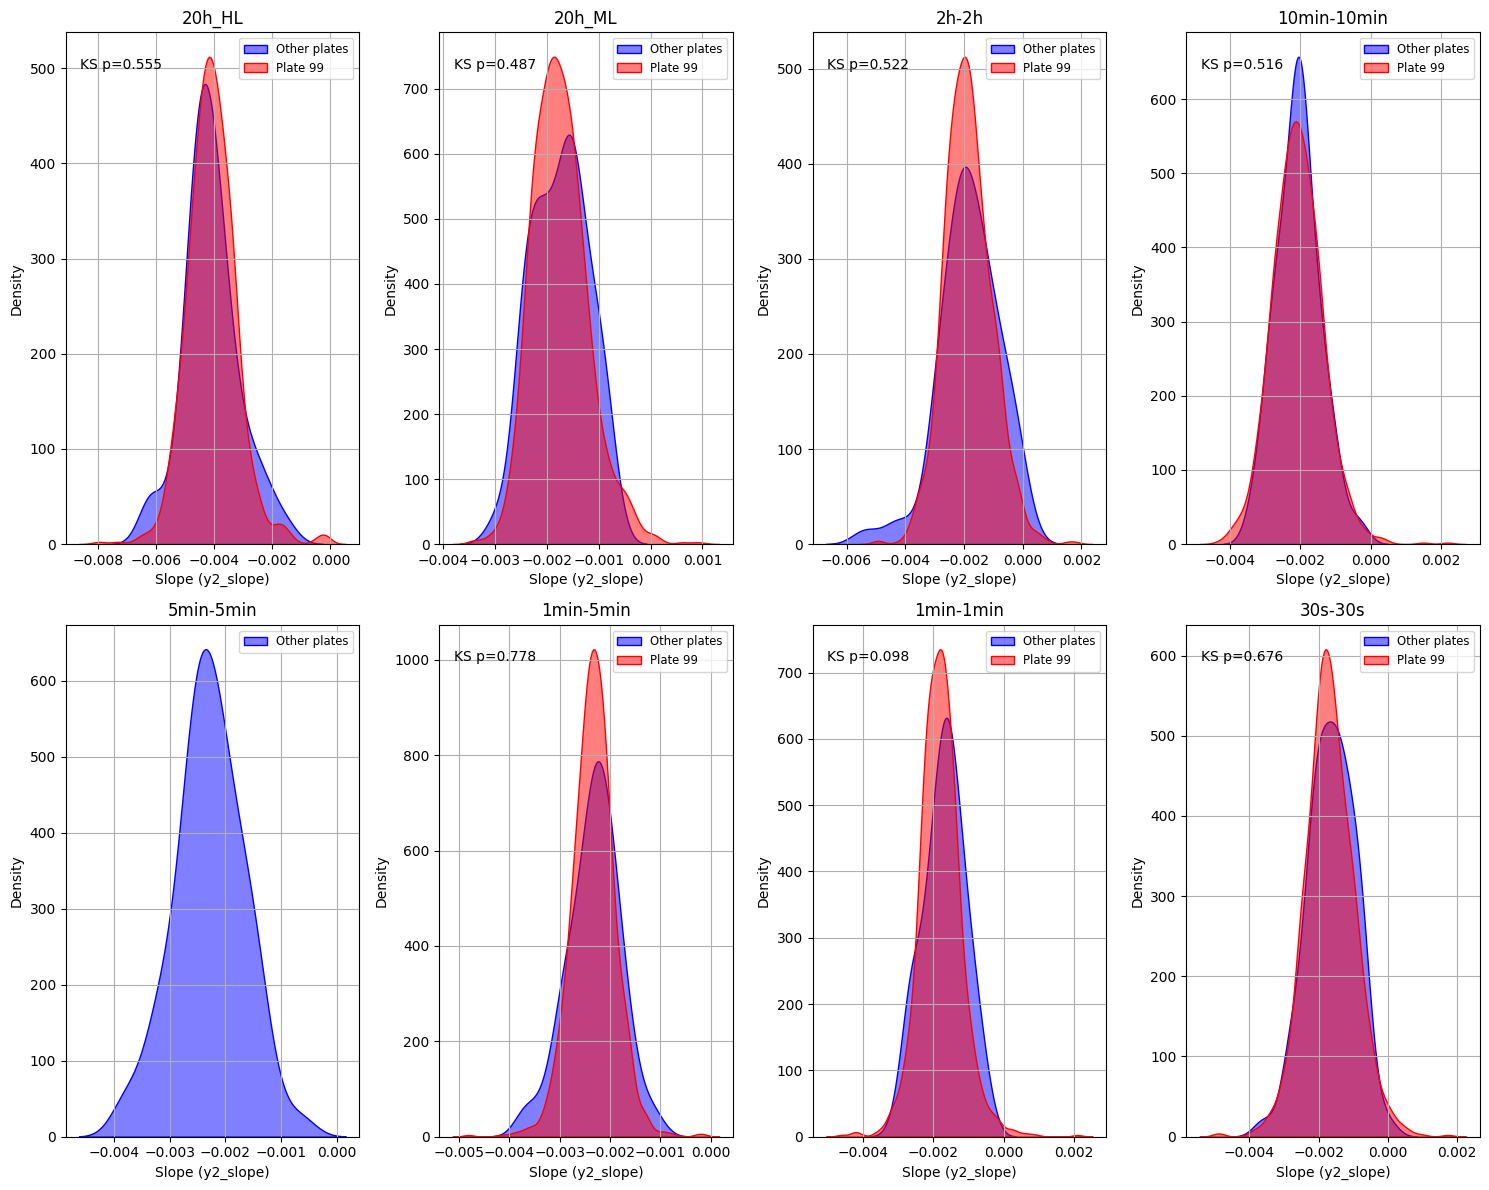

In [18]:
from scipy.stats import norm
from scipy.stats import shapiro, ks_2samp, kstest

#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/2025_5_phase2_light_status_slope_QtilNorm_randeffONLYPLATES_ontimepoints.csv')
normalised_wts = data[(data['mutant_ID'] == 'WT')]# & (data['plate']!='99')]

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']


n_rows = 2
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten() 

for i, light_regime in enumerate(light_regimes):
    ax = axes[i]  
    data_light = normalised_wts[normalised_wts['light_regime'] == light_regime]
    
    # slopes = data_light['y2_slope'].dropna()
    slopes_99 = data_light[data_light['plate'].astype(str).str.startswith('99')]['y2_slope'].dropna()
    slopes_other = data_light[data_light['plate'].astype(str).str.startswith('3')]['y2_slope'].dropna()
    
    if slopes_99.empty and slopes_other.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_title(f'{light_regime}')
        ax.axis('off')
        continue

    if not slopes_other.empty:
        sns.kdeplot(slopes_other, ax=ax, color='blue', fill=True, alpha=0.5, label='Other plates')

    if not slopes_99.empty:
        sns.kdeplot(slopes_99, ax=ax, color='red', fill=True, alpha=0.5, label='Plate 99')

    slopes_combined = pd.concat([slopes_99, slopes_other])
    mean, std = norm.fit(slopes_combined)
    shapiro_stat, shapiro_p = shapiro(slopes_combined)
    #ks_stat, ks_p = kstest(slopes_combined, 'norm', args=(mean, std))
    if not slopes_99.empty and not slopes_other.empty:
        ks_stat, ks_p = ks_2samp(slopes_99, slopes_other)
        ax.text(0.05, 0.95, f'KS p={ks_p:.3f}', #Shapiro p={shapiro_p:.3f}\n
                transform=ax.transAxes, fontsize=10, verticalalignment='top')

    ax.set_title(f'{light_regime}')
    ax.set_xlabel('Slope (y2_slope)')
    ax.set_ylabel('Density')
    ax.legend(fontsize='small')
    ax.grid(True)

for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
from scipy.stats import norm

wt_data = data[(data['plate'].astype(str).str.startswith('3')) & (data['mutant_ID'] == 'WT')]
non_wt_data = data[(data['plate'].astype(str).str.startswith('3')) & (data['mutant_ID'] == 'WT')]

mu_wt = wt_data['y2_slope'].mean()
sigma_wt = wt_data['y2_slope'].std() + non_wt_data['y2_slope'].std()

mutant_data = data[data['mutant_ID']!='WT']
mutant_data['z_score'] = (mutant_data['y2_slope'] - mu_wt) / sigma_wt
mutant_data['p_value'] = 2 * (1 - norm.cdf(np.abs(mutant_data['z_score'])))

#BH
mutant_data = mutant_data.sort_values('p_value')
mutant_data['rank'] = np.arange(1, len(mutant_data) + 1)
mutant_data['BH_threshold'] = (mutant_data['rank'] / len(mutant_data)) * 0.05
mutant_data['significant'] = mutant_data['p_value'] < mutant_data['BH_threshold']

print(mutant_data[['y2_slope', 'z_score', 'p_value', 'BH_threshold', 'significant']])

       y2_slope    z_score   p_value  BH_threshold  significant
23617 -0.014941 -11.442865  0.000000      0.000002         True
20381 -0.011745  -8.777244  0.000000      0.000003         True
20009 -0.012926  -9.762368  0.000000      0.000005         True
12140 -0.015250 -11.700382  0.000000      0.000007         True
14232  0.010073   9.419715  0.000000      0.000009         True
...         ...        ...       ...           ...          ...
15673 -0.001222  -0.000201  0.999840      0.049993        False
19009 -0.001221   0.000199  0.999841      0.049995        False
18974 -0.001222  -0.000161  0.999871      0.049997        False
18013 -0.001222  -0.000082  0.999935      0.049998        False
17155 -0.001221  -0.000067  0.999946      0.050000        False

[28866 rows x 5 columns]


/tmp/ipykernel_1331339/117921657.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutant_data['z_score'] = (mutant_data['y2_slope'] - mu_wt) / sigma_wt
/tmp/ipykernel_1331339/117921657.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutant_data['p_value'] = 2 * (1 - norm.cdf(np.abs(mutant_data['z_score'])))


### Slope trend graphs 

Plotting average slopes per gene across light regimes (saving them in pdf)

Comparing with myria's genes

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


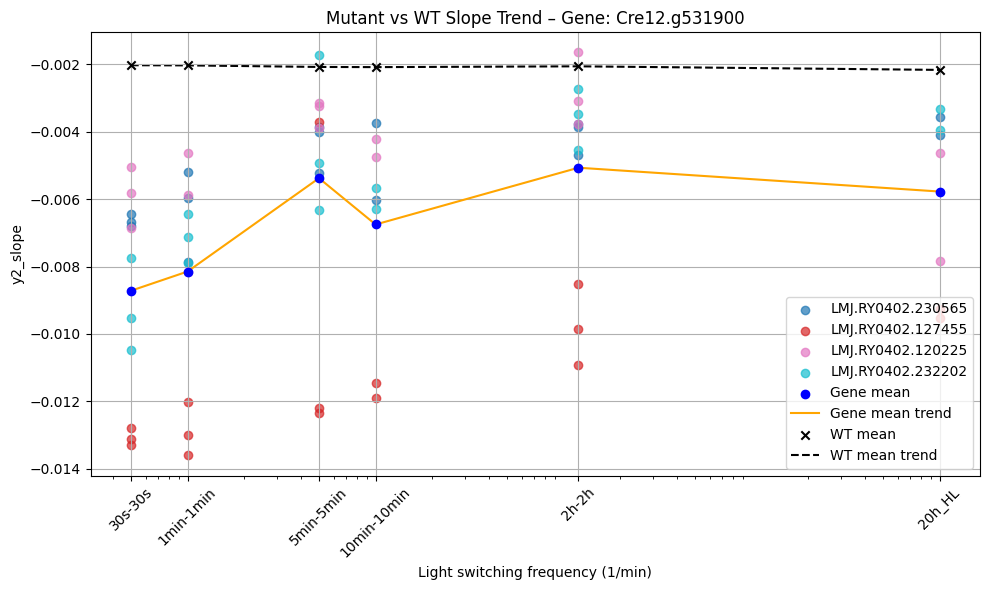

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


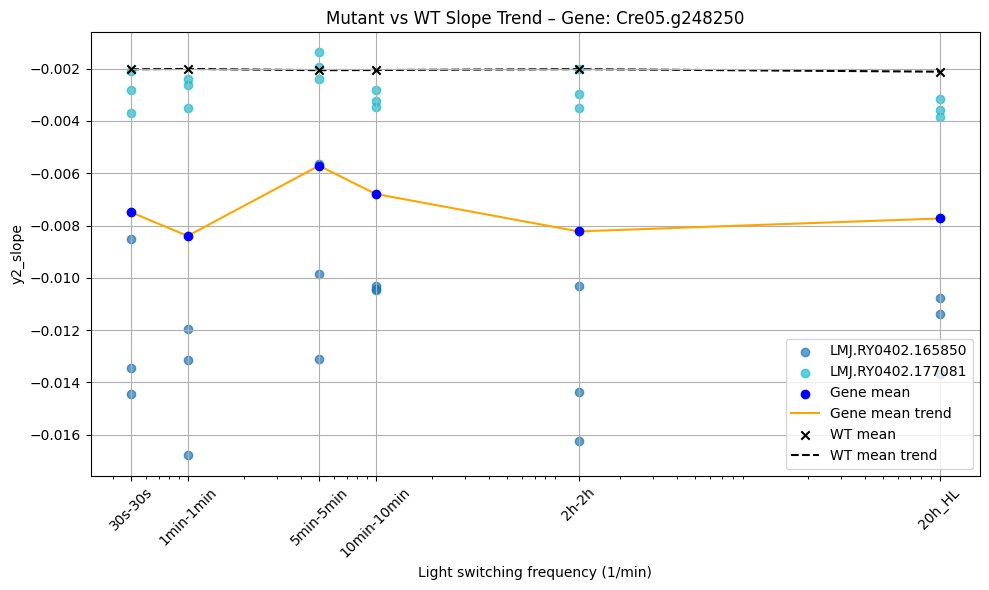

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


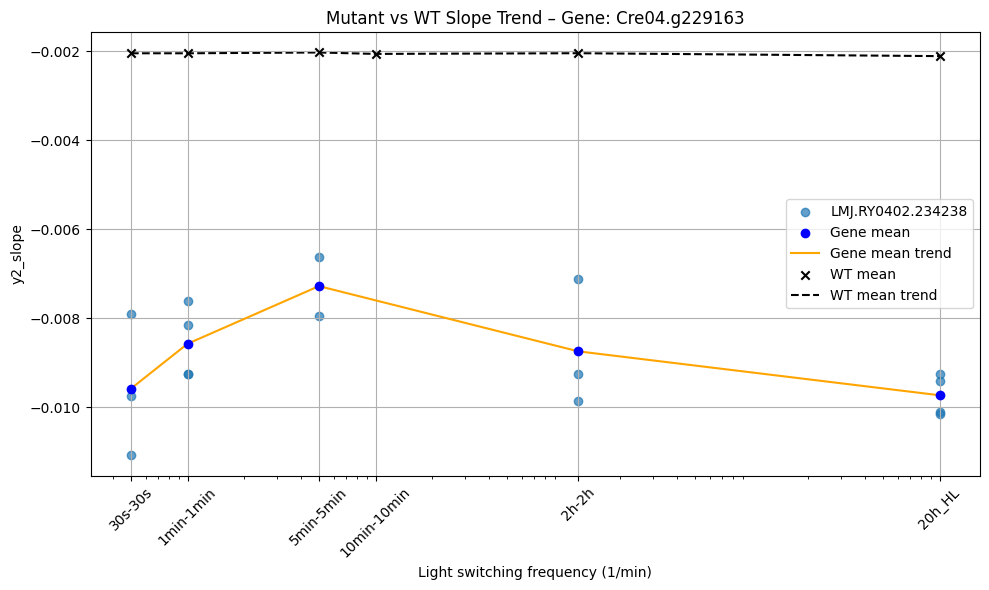

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


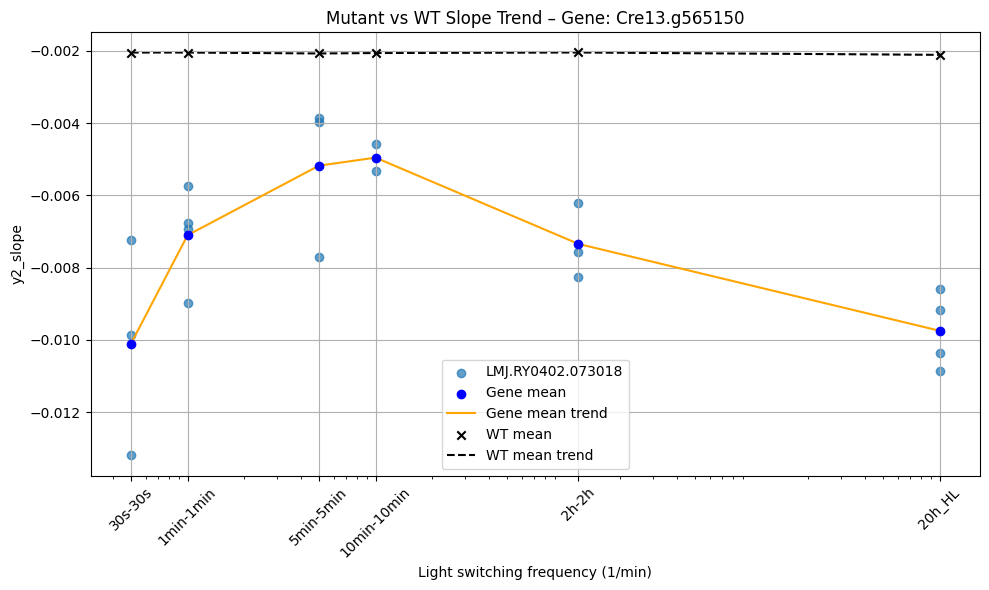

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


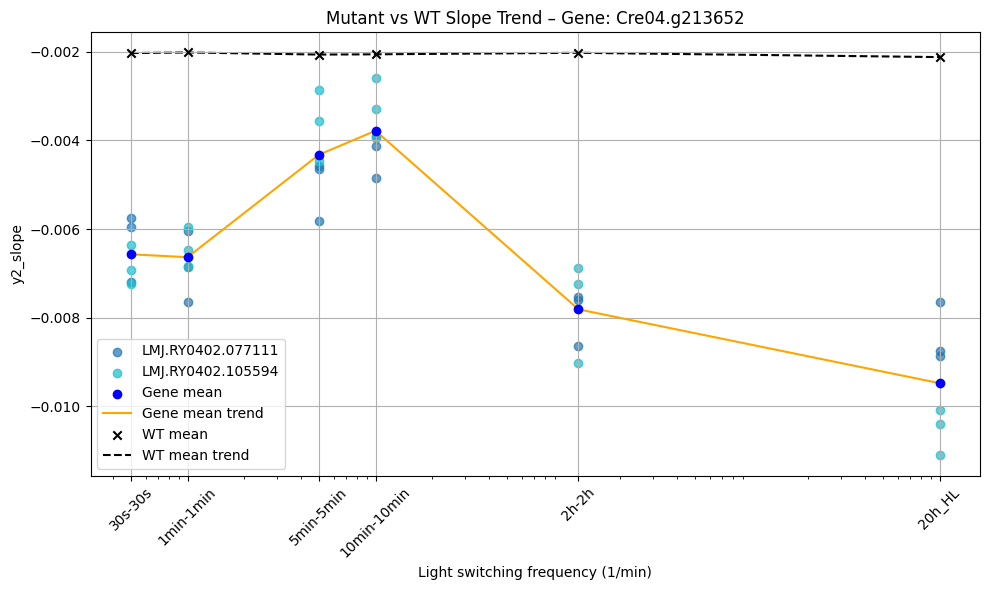

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


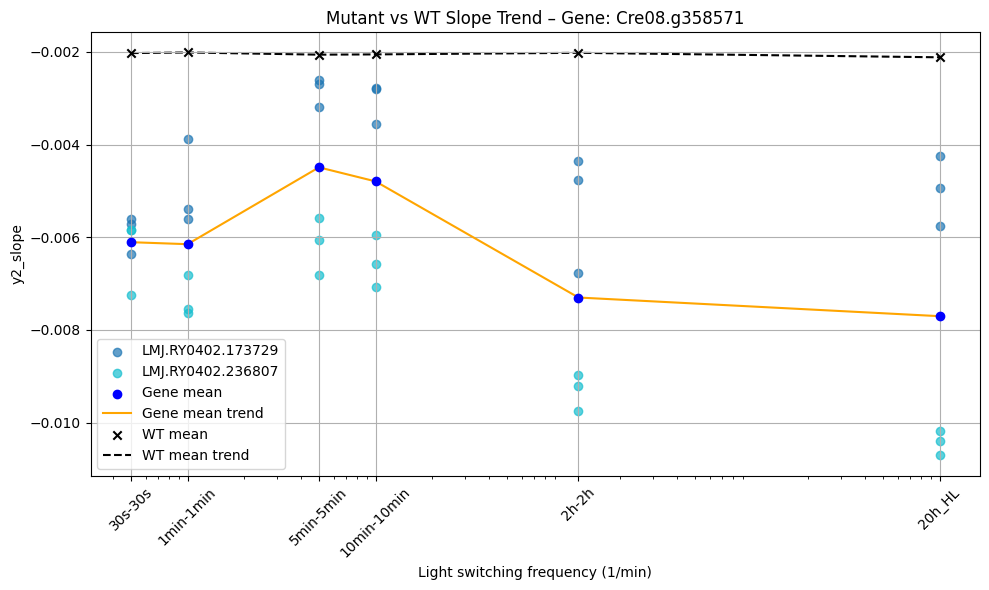

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


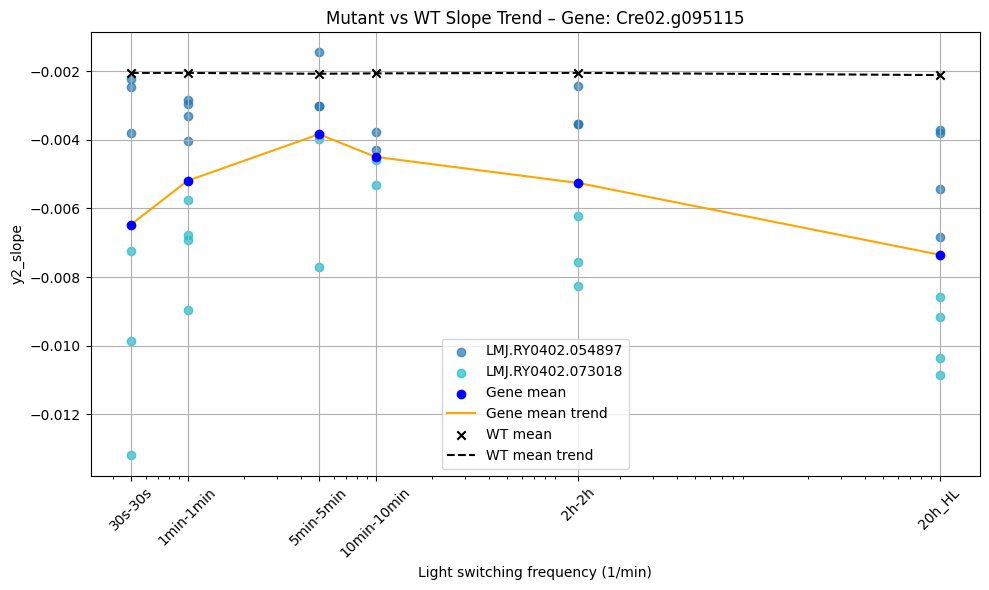

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


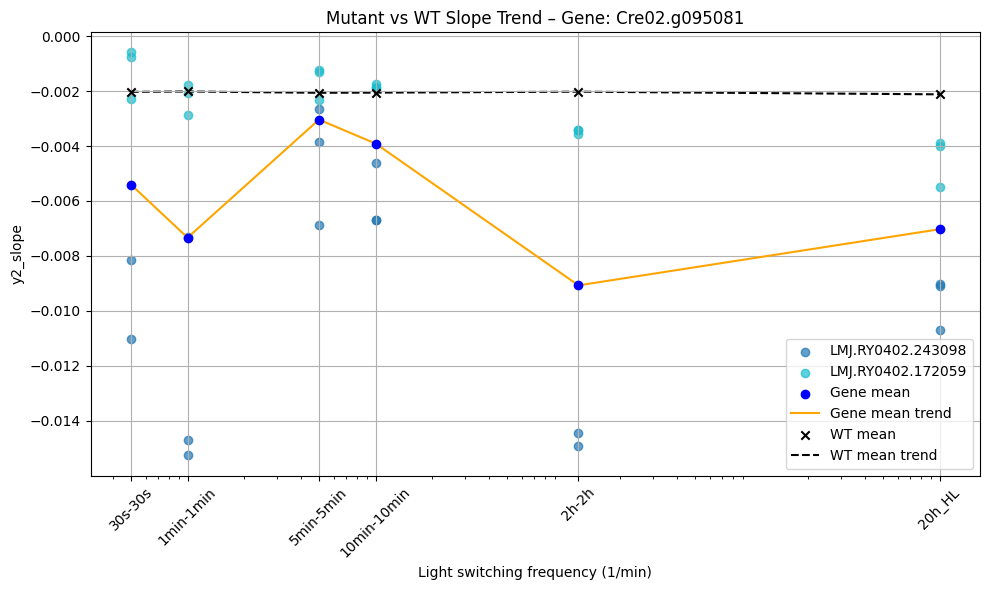

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


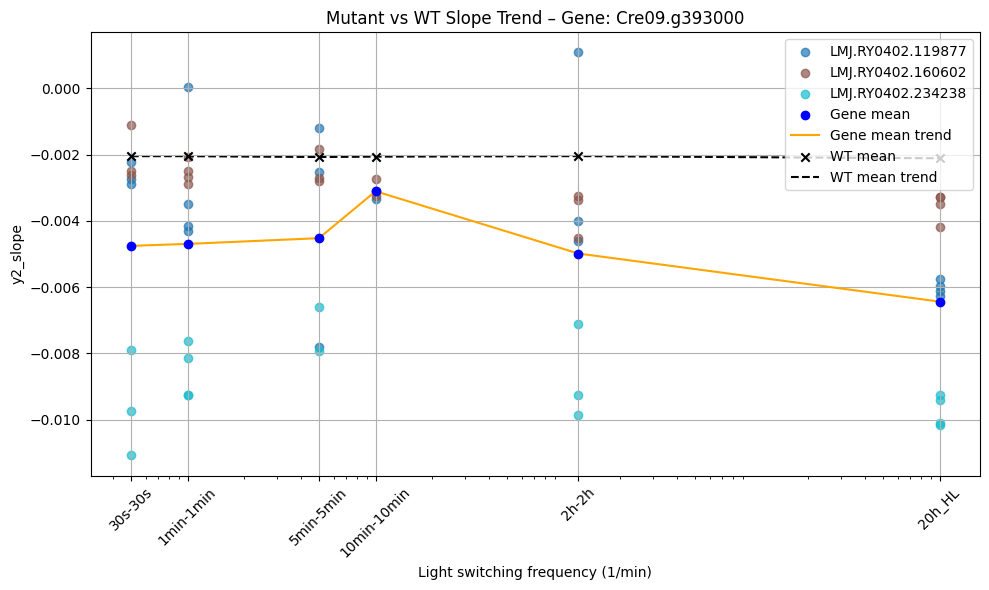

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


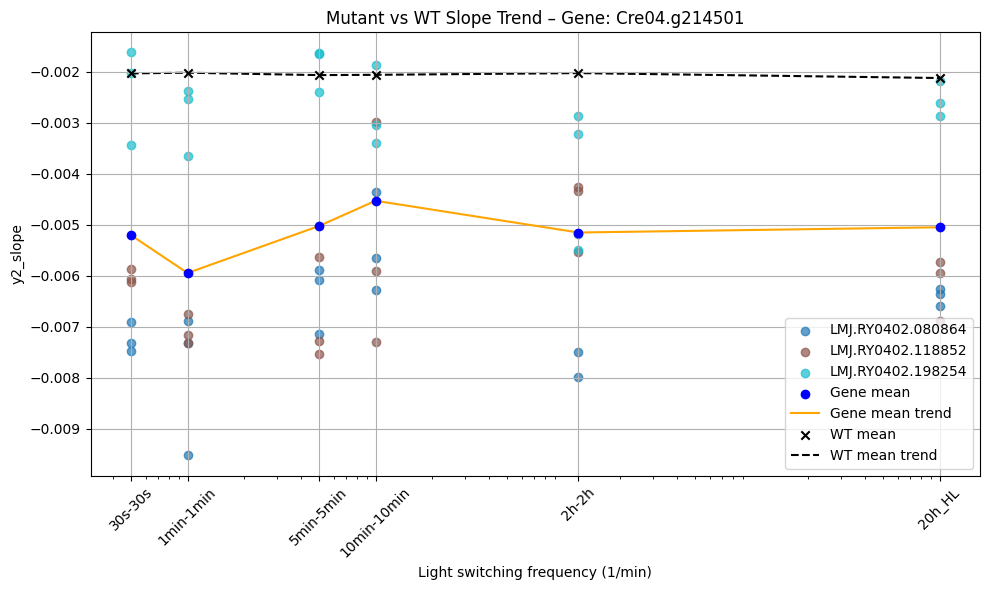

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


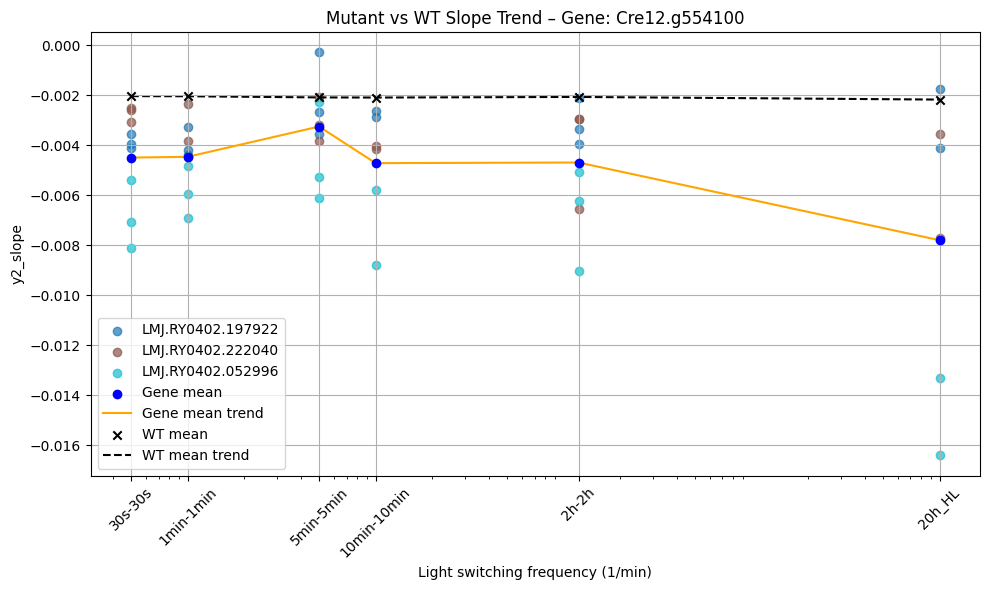

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


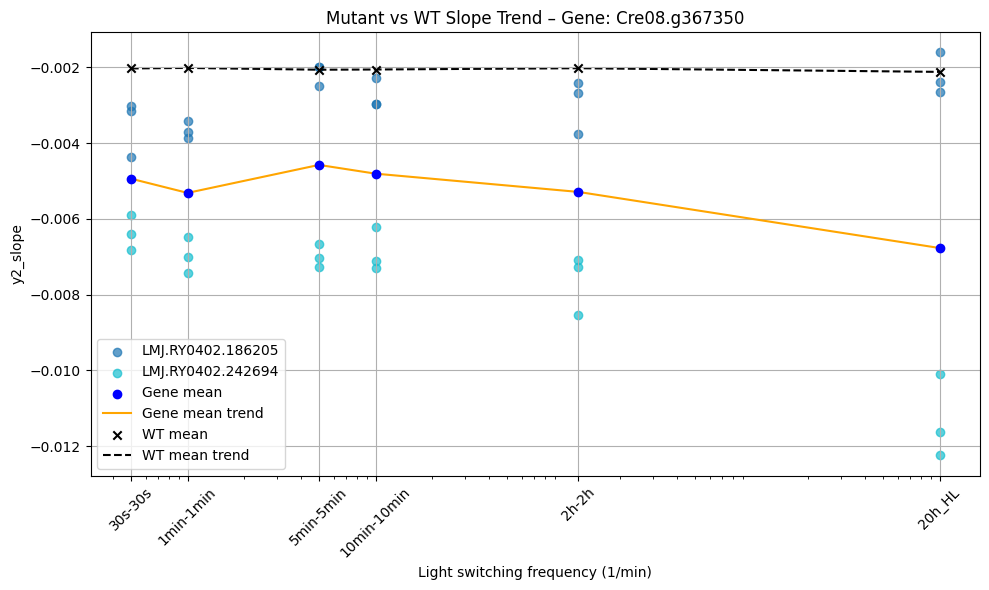

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


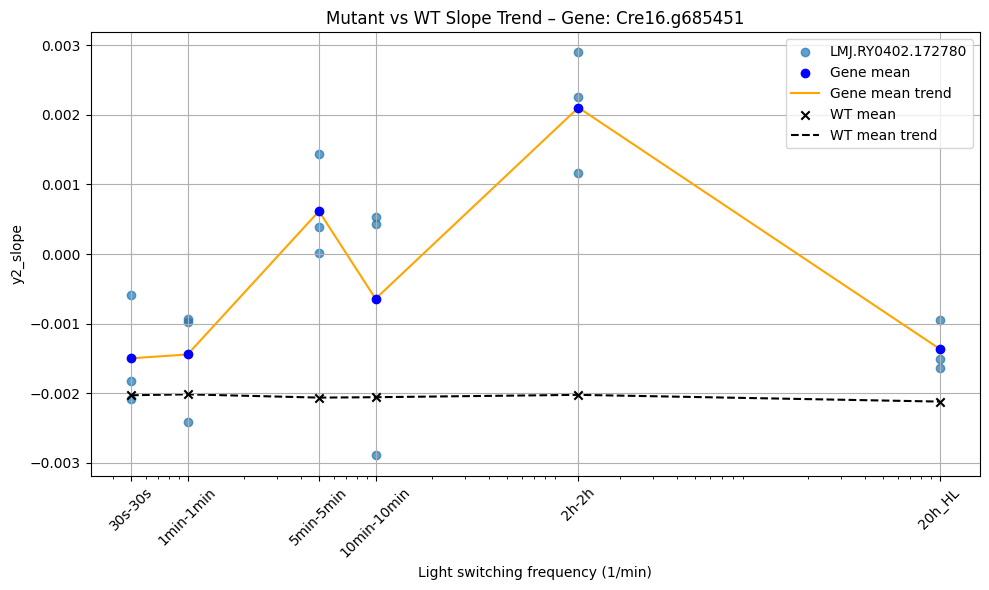

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


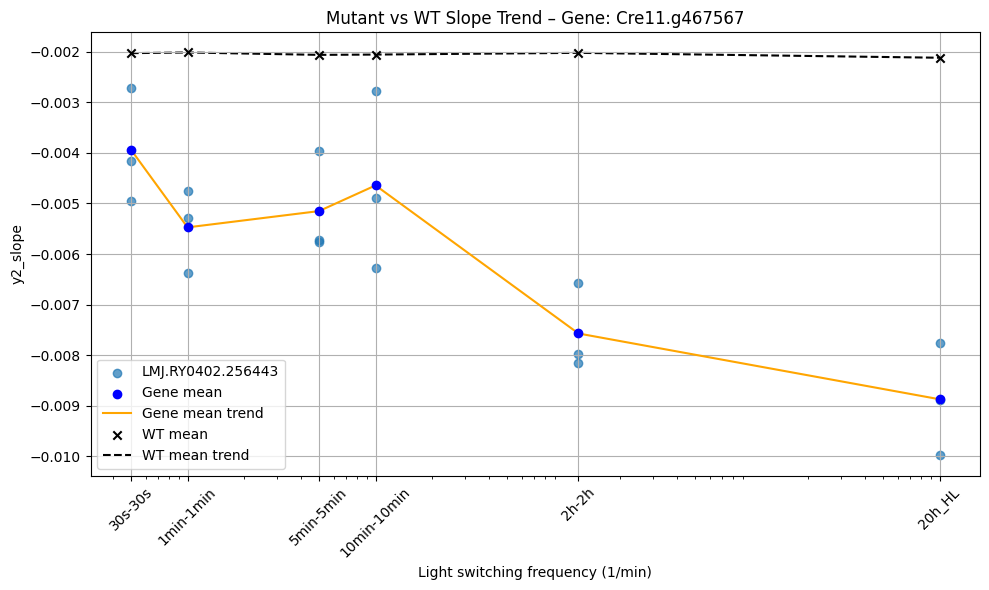

/tmp/ipykernel_187539/3858184296.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(mutants))


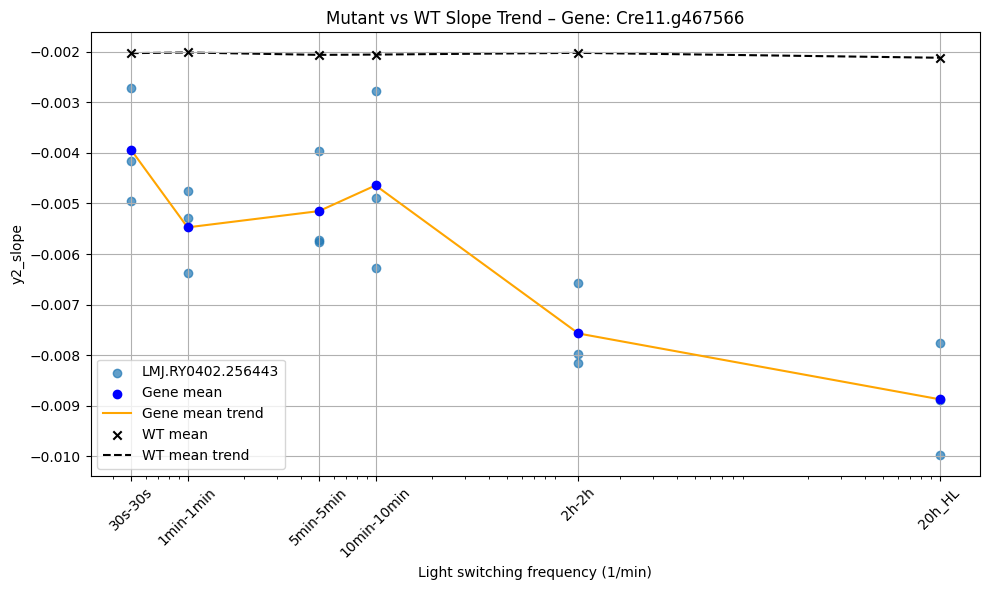


ANCOVA results for gene Cre11.g467566:

                  sum_sq     df           F        PR(>F)
freq            0.000006    1.0    7.608717  6.703131e-03
is_mutant       0.000234    1.0  304.793863  5.678410e-35
freq:is_mutant  0.000026    1.0   33.579137  5.467771e-08
Residual        0.000093  122.0         NaN           NaN


In [ ]:
import numpy as np
import pandas as pd
from numpy.polynomial.polynomial import Polynomial
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# LABELED BY MUTANT ID
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayes+flatWTs_split_genes_slope&zscore.csv')
data['y2_slope']=data['y2_slope_mixed_centered']
# Light regime order and frequency mapping
# regime_order = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-1min', '30s-30s']
# regime_to_freq = {regime: i / (len(regime_order) - 1) for i, regime in enumerate(regime_order)}

#  frequencies in 1/min
regime_to_freq = {
    '20h_HL': 10000,                     
    '2h-2h': 120,                
    '10min-10min': 10,          
    '5min-5min': 5,
    '1min-1min': 1,
    '30s-30s': 0.5           
}
regime_order = list(regime_to_freq.keys())

for gene in ['Cre12.g531900', 'Cre05.g248250', 'Cre04.g229163', 'Cre13.g565150', 'Cre04.g213652', 'Cre08.g358571', 'Cre02.g095115', 'Cre02.g095081', 'Cre09.g393000', 'Cre04.g214501', 'Cre12.g554100', 'Cre08.g367350', 'Cre16.g685451', 'Cre11.g467567', 'Cre11.g467566']:
    # if gene not in data['mutated_genes'].unique():
    #     print(f'{gene} not present in dataset')
    #     continue
    gene_data = data[
        (data['mutated_genes'].astype(str).str.contains(gene)) &
        (data['light_regime'].isin(regime_order)) &
        (~data['y2_slope'].isna())
    ].copy()
    gene_data['freq'] = gene_data['light_regime'].map(regime_to_freq)

    plates = gene_data['plate'].unique()
    wt_data = data[
        (data['mutated_genes'] == 'WT') &
        (data['plate'].isin(plates)) &
        (data['light_regime'].isin(regime_order)) &
        (~data['y2_slope'].isna())
    ].copy()
    wt_data['freq'] = wt_data['light_regime'].map(regime_to_freq)

    mutant_means = gene_data.groupby(['mutant_ID', 'light_regime']).agg(
        mean_y2_slope=('y2_slope', 'mean')
    ).reset_index()

    gene_agg = mutant_means.groupby('light_regime').agg(
        mean_y2_slope=('mean_y2_slope', 'mean')
    ).reset_index()

    gene_agg['freq'] = gene_agg['light_regime'].map(regime_to_freq)

    wt_agg = wt_data.groupby('light_regime').agg(
        mean_y2_slope=('y2_slope', 'mean')
    ).reset_index()
    wt_agg['freq'] = wt_agg['light_regime'].map(regime_to_freq)

    x_gene = gene_agg['freq'].values
    y_gene = gene_agg['mean_y2_slope'].values

    x_wt = wt_agg['freq'].values
    y_wt = wt_agg['mean_y2_slope'].values
    gene_agg = gene_agg.sort_values("freq")
    wt_agg = wt_agg.sort_values("freq")


    plt.figure(figsize=(10, 6))
    mutants = gene_data['mutant_ID'].unique()
    colors = cm.get_cmap('tab10', len(mutants)) 
    for i, mutant in enumerate(mutants):
        mutant_df = gene_data[gene_data['mutant_ID'] == mutant]
        plt.scatter(
            mutant_df['freq'],
            mutant_df['y2_slope'],
            label=mutant,
            color=colors(i),
            alpha=0.7
        )

    plt.xscale('log')

    plt.scatter(x_gene, y_gene, color='blue', label="Gene mean", zorder=3)
    plt.plot(gene_agg['freq'], gene_agg['mean_y2_slope'], color='orange', label="Gene mean trend", zorder=2)

    plt.scatter(x_wt, y_wt, color='black', label="WT mean", zorder=3, marker='x')
    plt.plot(wt_agg['freq'], wt_agg['mean_y2_slope'], color='black', linestyle='--', label="WT mean trend", zorder=1)

    # equidistant
    # plt.xticks(ticks=list(regime_to_freq.values()), labels=regime_order, rotation=45)
    # plt.xlabel("Light Regime (low to high frequency)")
    
    # freq scale
    plt.xticks(
        ticks=[regime_to_freq[r] for r in regime_order],
        labels=regime_order,
        rotation=45
    )
    plt.xlabel("Light switching frequency (1/min)")

    plt.ylabel("y2_slope")
    plt.title(f"Mutant vs WT Slope Trend – Gene: {gene}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Combine WT and mutant data
gene_data['is_mutant'] = 1
wt_data['is_mutant'] = 0

combined_data = pd.concat([gene_data, wt_data], ignore_index=True)

# Fit the ANCOVA model
model = ols('y2_slope ~ freq * is_mutant', data=combined_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(f"\nANCOVA results for gene {gene}:\n")
print(anova_table)


In [ ]:
from Scripts_Imane import file_generation
import pandas as pd
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayes+flatWTs_split_genes_slope&zscore.csv')
data['y2_slope'] = data['y2_slope_mixed_centered']
genes = data['mutated_genes'].unique()
file_generation.pdf_slopetrend(data,genes)

/tmp/ipykernel_45181/1833325372.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', len(plates))


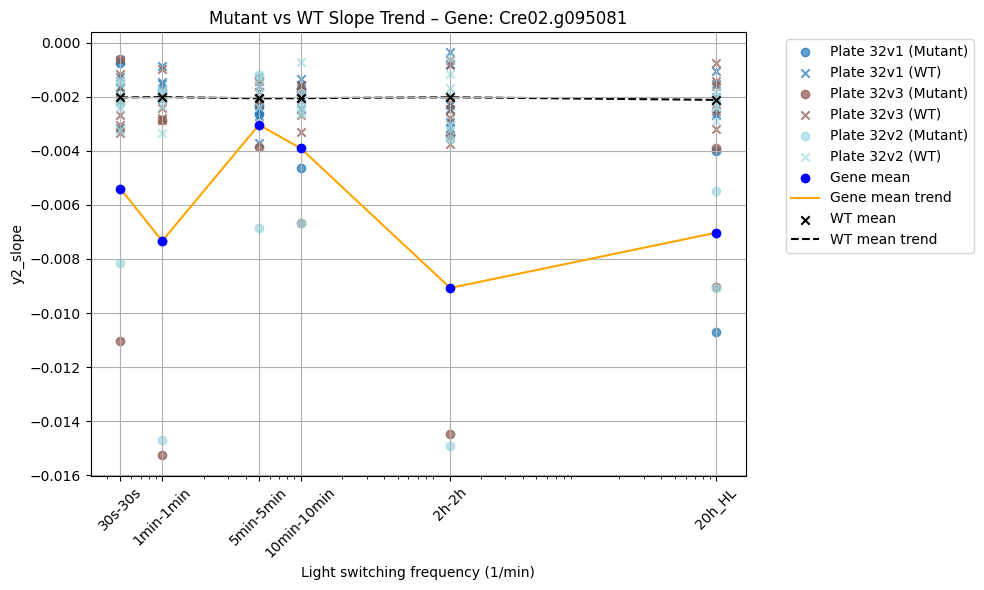

In [ ]:
## LABELED BY PLATE 
# Load data
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayes+flatWTs_split_genes_slope&zscore.csv')
data['y2_slope'] = data['y2_slope_mixed_centered']
# Frequencies
regime_to_freq = {
    '20h_HL': 10000,
    '2h-2h': 120,
    '10min-10min': 10,
    '5min-5min': 5,
    '1min-1min': 1,
    '30s-30s': 0.5
}
regime_order = list(regime_to_freq.keys())

for gene in ['Cre02.g095081']:
    gene_data = data[
        (data['mutated_genes'].astype(str).str.contains(gene)) &
        (data['light_regime'].isin(regime_order)) &
        (~data['y2_slope'].isna())
    ].copy()
    gene_data['freq'] = gene_data['light_regime'].map(regime_to_freq)

    plates = gene_data['plate'].unique()
    wt_data = data[
        (data['mutated_genes'] == 'WT') &
        (data['plate'].isin(plates)) &
        (data['light_regime'].isin(regime_order)) &
        (~data['y2_slope'].isna())
    ].copy()
    wt_data['freq'] = wt_data['light_regime'].map(regime_to_freq)

    # Mean of each mutant per light regime
    mutant_means = gene_data.groupby(['mutant_ID', 'light_regime']).agg(
        mean_y2_slope=('y2_slope', 'mean')
    ).reset_index()

    gene_agg = mutant_means.groupby('light_regime').agg(
        mean_y2_slope=('mean_y2_slope', 'mean')
    ).reset_index()
    gene_agg['freq'] = gene_agg['light_regime'].map(regime_to_freq)

    wt_agg = wt_data.groupby('light_regime').agg(
        mean_y2_slope=('y2_slope', 'mean')
    ).reset_index()
    wt_agg['freq'] = wt_agg['light_regime'].map(regime_to_freq)

    gene_agg = gene_agg.sort_values("freq")
    wt_agg = wt_agg.sort_values("freq")

    x_gene = gene_agg['freq'].values
    y_gene = gene_agg['mean_y2_slope'].values
    x_wt = wt_agg['freq'].values
    y_wt = wt_agg['mean_y2_slope'].values

    # === Plot ===
    plt.figure(figsize=(10, 6))

    colors = cm.get_cmap('tab20', len(plates))
    for i, plate in enumerate(plates):
        color = colors(i)
        plate_mutants = gene_data[gene_data['plate'] == plate]
        plate_wts = wt_data[wt_data['plate'] == plate]

        # Plot mutant points
        plt.scatter(
            plate_mutants['freq'],
            plate_mutants['y2_slope'],
            label=f'Plate {plate} (Mutant)',
            color=color,
            alpha=0.7
        )
        # Plot WT points from same plate
        plt.scatter(
            plate_wts['freq'],
            plate_wts['y2_slope'],
            label=f'Plate {plate} (WT)',
            color=color,
            alpha=0.7,
            marker='x'
        )

    # Mean & trend lines
    plt.scatter(x_gene, y_gene, color='blue', label="Gene mean", zorder=3)
    plt.plot(gene_agg['freq'], gene_agg['mean_y2_slope'], color='orange', label="Gene mean trend", zorder=2)

    plt.scatter(x_wt, y_wt, color='black', label="WT mean", zorder=3, marker='x')
    plt.plot(wt_agg['freq'], wt_agg['mean_y2_slope'], color='black', linestyle='--', label="WT mean trend", zorder=1)

    plt.xscale('log')
    plt.xticks(
        ticks=[regime_to_freq[r] for r in regime_order],
        labels=regime_order,
        rotation=45
    )
    plt.xlabel("Light switching frequency (1/min)")
    plt.ylabel("y2_slope")
    plt.title(f"Mutant vs WT Slope Trend – Gene: {gene}")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


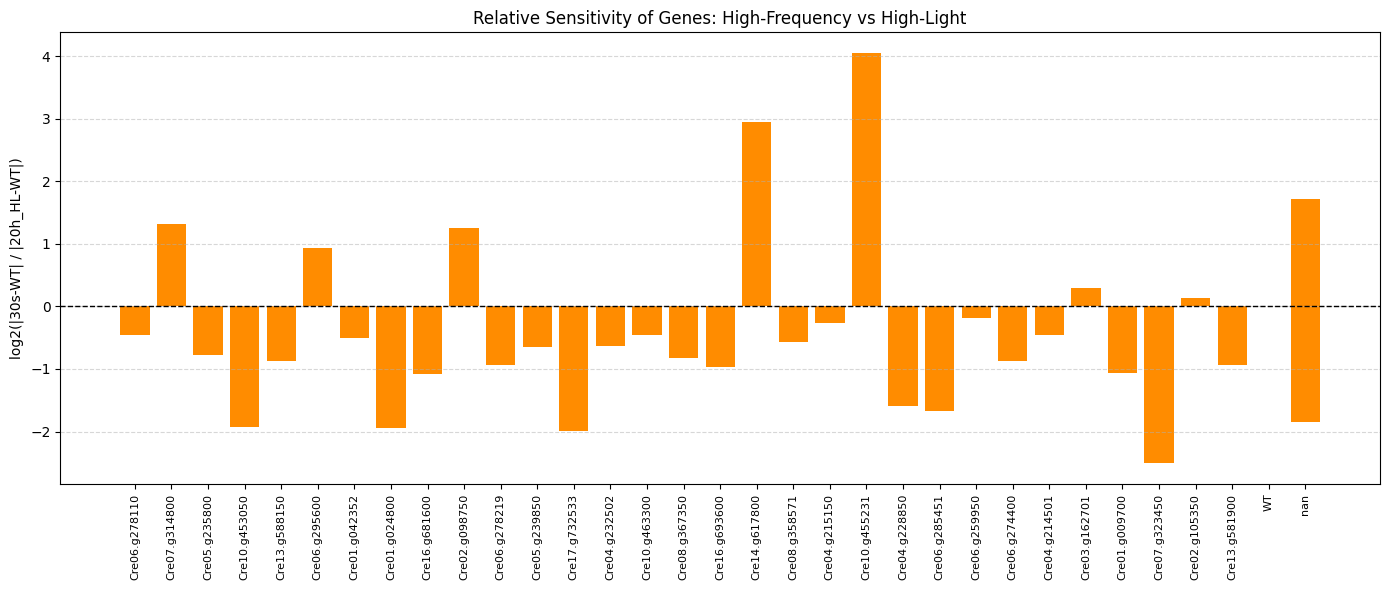

In [ ]:
# List of genes to evaluate
#Myria's genes
high_freq= [
    'Cre03.g162701', 'Cre15.g635800', 'Cre01.g042352', 'Cre05.g235800', 'Cre16.g693600',
    'Cre16.g661200', 'Cre13.g588150', 'Cre16.g664150', 'Cre09.g386850', 'Cre06.g278110',
    'Cre02.g098750', 'Cre04.g228850', 'Cre12.g560668', 'Cre01.g009700', 'Cre03.g162701',
    'Cre14.g617800', 'Cre02.g105350', 'Cre10.g455231', 'Cre06.g259950'
]

high_light_freq = [
    'Cre10.g463300', 'Cre04.g232502', 'Cre06.g274400', 'Cre07.g323450', 'Cre08.g367350',
    'Cre13.g581900', 'Cre06.g295600', 'Cre09.g399663', 'Cre08.g358571', 'Cre07.g314800',
    'Cre06.g278219', 'Cre03.g168900', 'Cre05.g239850', 'Cre10.g430900', 'Cre16.g681600',
    'Cre17.g732533', 'Cre10.g453050', 'Cre12.g531900', 'Cre01.g024800'
]

high_light = [
    'Cre04.g215150', 'Cre17.g746397', 'Cre06.g285451', 'Cre04.g214501'
]
genes = high_freq + high_light + high_light_freq + ['WT']
custom_order = [
    'Cre06.g278110', 'Cre07.g314800', 'Cre05.g235800', 'Cre10.g453050', 'Cre13.g588150',
    'Cre06.g295600', 'Cre09.g99663', 'Cre01.g042352', 'Cre01.g024800', 'Cre16.g681600',
    'Cre12.g331900', 'Cre02.g098750', 'Cre06.g278219', 'Cre05.g239850', 'Cre17.g732533',
    'Cre04.g232502', 'Cre10.g463300', 'Cre08.g367350', 'Cre16.g693600', 'Cre09.g388650',
    'Cre14.g617800', 'Cre10.g439000', 'Cre08.g358571', 'Cre04.g215150', 'Cre12.g606668',
    'Cre10.g455231', 'Cre04.g228850', 'Cre06.g285451', 'Cre06.g259950',
    'Cre06.g274400', 'Cre04.g214501', 'Cre03.g162701', 'Cre01.g009700', 'Cre07.g323450',
    'Cre02.g105350', 'Cre13.g581900', 'WT'
]

wt_data = data[data['mutated_genes'] == 'WT']
wt_means = wt_data.groupby('light_regime').agg(mean_y2_slope=('y2_slope', 'mean'))
ratios = []
epsilon = 1e-6  # small constant to avoid division by 0
for gene in genes:
    gene_data = data[(data['mutated_genes'].astype(str).str.contains(gene)) & (~data['y2_slope'].isna())]
    mutant_means = gene_data.groupby(['mutant_ID', 'light_regime']).agg(
        mean_y2_slope=('y2_slope', 'mean')
    ).reset_index()

    gene_means = mutant_means.groupby('light_regime').agg(
        mean_y2_slope=('mean_y2_slope', 'mean')
    )
    if '30s-30s' in gene_means.index and '20h_HL' in gene_means.index:
        gene_FL = gene_means.loc['30s-30s', 'mean_y2_slope']
        gene_HL = gene_means.loc['20h_HL', 'mean_y2_slope']

        if '30s-30s' in wt_means.index and '20h_HL' in wt_means.index:
            wt_FL = wt_means.loc['30s-30s', 'mean_y2_slope']
            wt_HL = wt_means.loc['20h_HL', 'mean_y2_slope']

            dist_FL = np.abs(gene_FL - wt_FL)
            dist_HL = np.abs(gene_HL - wt_HL)

            # Compute log2 of distance ratio
            log_ratio = np.log2((dist_FL + epsilon) / (dist_HL + epsilon))
            ratios.append((gene, log_ratio))
ratio_df = pd.DataFrame(ratios, columns=['gene', 'log2_FL_HL_ratio'])
ratio_df['gene'] = pd.Categorical(ratio_df['gene'], categories=custom_order, ordered=True)
ratio_df = ratio_df.sort_values('gene')
ratio_df['gene'] = ratio_df['gene'].astype(str)
plt.figure(figsize=(14, 6))
plt.bar(ratio_df['gene'], ratio_df['log2_FL_HL_ratio'], color='darkorange')
plt.xticks(rotation=90, fontsize=8)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.ylabel('log2(|30s-WT| / |20h_HL-WT|)')
plt.title('Relative Sensitivity of Genes: High-Frequency vs High-Light')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
